# Homework 2 — Response Clarity Classification
**Course:** Artificial Intelligence II — Deep Learning for NLP  
**Dataset:** SemEval 2026 Task 6 (QEvasion)  
**Models:** `bert-base-uncased` · `distilbert-base-uncased` · `microsoft/deberta-v3-base`  
**Metric:** Macro F1-Score  

---
### Input Construction Design

We pass the question and answer as **two separate sequences** to each tokenizer:

```
BERT / DistilBERT : [CLS] <question> [SEP] <answer> [SEP]
DeBERTa-v3        : [CLS] <question> [SEP] <answer> [SEP]   (no token_type_ids)
```

The tokenizer handles separator injection and segment IDs automatically. This mirrors the standard NSP pre-training format for BERT and gives the model an explicit Q/A boundary without manual text manipulation.


In [1]:
!pip install -q sentencepiece

In [2]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["HF_HUB_DOWNLOAD_TIMEOUT"] = "120"
os.environ["HF_HUB_HTTP_BACKOFF_FACTOR"] = "1"
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from datasets import load_dataset
from sklearn.metrics import (
    classification_report, f1_score, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

# ── Reproducibility ──────────────────────────────────────────────────────────
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
COLORS = ["#4C72B0", "#DD8452", "#55A868"]
print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

SEED = 42
def seed_all(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = True; torch.backends.cudnn.benchmark = False
seed_all(SEED)


Device: cuda
GPU: Tesla T4


## 1. Load Data

In [3]:
ds       = load_dataset("ailsntua/QEvasion")
df_train = pd.DataFrame(ds["train"])
df_test  = pd.DataFrame(ds["test"])

print("Train size:", len(df_train))
print("Test  size:", len(df_test))
print("\nLabel distribution (train):")
print(df_train["clarity_label"].value_counts())
df_train.head(3)

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/3.90M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/259k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3448 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/308 [00:00<?, ? examples/s]

Train size: 3448
Test  size: 308

Label distribution (train):
clarity_label
Ambivalent         2040
Clear Reply        1052
Clear Non-Reply     356
Name: count, dtype: int64


,title,date,president,url,question_order,interview_question,interview_answer,gpt3.5_summary,gpt3.5_prediction,question,annotator_id,annotator1,annotator2,annotator3,inaudible,multiple_questions,affirmative_questions,index,clarity_label,evasion_label
0,"The President's News Conference in Hanoi, Vietnam","September 10, 2023",Joseph R. Biden,https://www.presidency.ucsb.edu/documents/the-...,1,Q. Of the Biden administration. And accused th...,"Well, look, first of all, theI am sincere abou...",The question consists of 2 parts: \n1. How wou...,Question part: 1. How would you respond to the...,How would you respond to the accusation that t...,85,None,None,None,False,False,False,0,Clear Reply,Explicit
1,"The President's News Conference in Hanoi, Vietnam","September 10, 2023",Joseph R. Biden,https://www.presidency.ucsb.edu/documents/the-...,1,Q. Of the Biden administration. And accused th...,"Well, look, first of all, theI am sincere abou...",The question consists of 2 parts: \n1. How wou...,Question part: 1. How would you respond to the...,Do you think President Xi is being sincere abo...,85,None,None,None,False,False,False,1,Ambivalent,General
2,"The President's News Conference in Hanoi, Vietnam","September 10, 2023",Joseph R. Biden,https://www.presidency.ucsb.edu/documents/the-...,2,Q. No worries. Do you believe the country's sl...,"Look, I think China has a difficult economic p...",The question consists of two parts:\n\n1. Q1: ...,Question part: Q1 - Do you believe the country...,Do you believe the country's slowdown and gro...,85,None,None,None,False,False,False,2,Ambivalent,Partial/half-answer


## 2. Exploratory Data Analysis

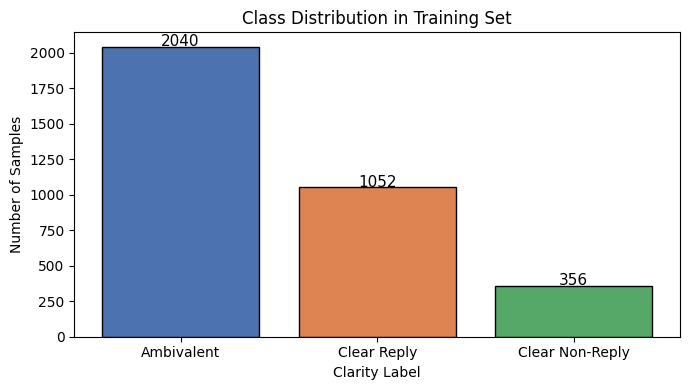

In [4]:
label_counts = df_train["clarity_label"].value_counts()

plt.figure(figsize=(7, 4))
bars = plt.bar(label_counts.index, label_counts.values, color=COLORS, edgecolor="black")
for bar, val in zip(bars, label_counts.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
             str(val), ha="center", fontsize=11)
plt.title("Class Distribution in Training Set")
plt.xlabel("Clarity Label")
plt.ylabel("Number of Samples")
plt.tight_layout()
plt.savefig("eda_class_distribution.png", dpi=300)
plt.show()

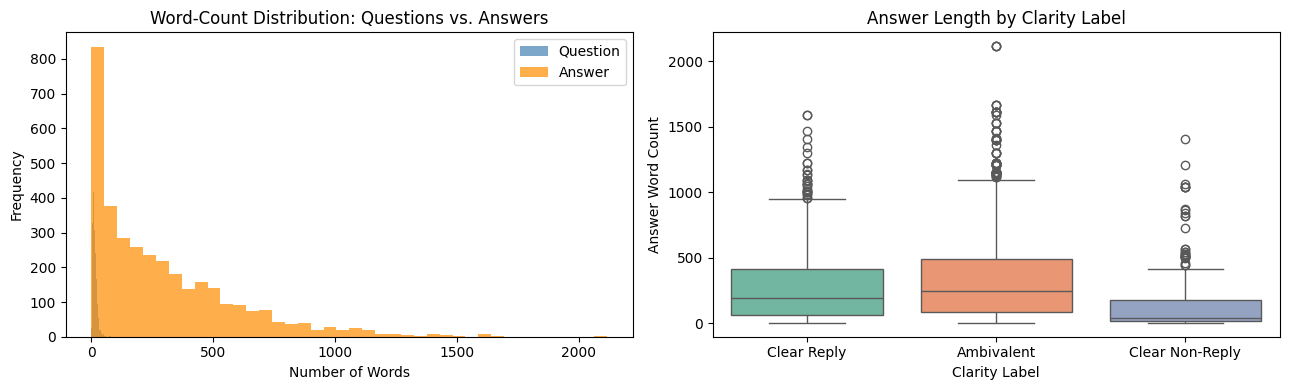


Median answer length per class:
clarity_label
Ambivalent         243.5
Clear Non-Reply     39.5
Clear Reply        194.0
Name: a_length, dtype: float64


In [5]:
df_train["q_length"] = df_train["question"].apply(lambda x: len(str(x).split()))
df_train["a_length"] = df_train["interview_answer"].apply(lambda x: len(str(x).split()))
df_test["q_length"]  = df_test["question"].apply(lambda x: len(str(x).split()))
df_test["a_length"]  = df_test["interview_answer"].apply(lambda x: len(str(x).split()))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(df_train["q_length"], bins=40, alpha=0.7, label="Question", color="steelblue")
axes[0].hist(df_train["a_length"], bins=40, alpha=0.7, label="Answer",   color="darkorange")
axes[0].set_title("Word-Count Distribution: Questions vs. Answers")
axes[0].set_xlabel("Number of Words"); axes[0].set_ylabel("Frequency"); axes[0].legend()

sns.boxplot(
    data=df_train, x="clarity_label", y="a_length", hue="clarity_label",
    order=["Clear Reply", "Ambivalent", "Clear Non-Reply"],
    palette="Set2", legend=False, ax=axes[1],
)
axes[1].set_title("Answer Length by Clarity Label")
axes[1].set_xlabel("Clarity Label"); axes[1].set_ylabel("Answer Word Count")

plt.tight_layout(); plt.savefig("eda_lengths.png", dpi=300); plt.show()
print("\nMedian answer length per class:")
print(df_train.groupby("clarity_label")["a_length"].median())

## 3. Label Encoding & Train / Validation Split

In [6]:
LABELS     = ["Clear Reply", "Ambivalent", "Clear Non-Reply"]
LABEL2ID   = {l: i for i, l in enumerate(LABELS)}
ID2LABEL   = {i: l for l, i in LABEL2ID.items()}
NUM_LABELS = len(LABELS)

df_train["label_id"] = df_train["clarity_label"].map(LABEL2ID)

df_tr, df_val = train_test_split(
    df_train, test_size=0.10, stratify=df_train["label_id"], random_state=RANDOM_SEED,
)
df_tr  = df_tr.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)

print(f"Train subset : {len(df_tr)}   Validation : {len(df_val)}")
print("Val label distribution:")
print(df_val["clarity_label"].value_counts())

Train subset : 3103   Validation : 345
Val label distribution:
clarity_label
Ambivalent         204
Clear Reply        105
Clear Non-Reply     36
Name: count, dtype: int64


## 4. Dataset, DataLoaders & Training Utilities


In [7]:
seed_all(SEED)  # Re-seed before model init
class ClarityDataset(Dataset):
    def __init__(self, df, tokenizer, max_len, has_labels=True):
        self.questions  = df["question"].tolist()
        self.answers    = df["interview_answer"].tolist()
        self.labels     = df["label_id"].tolist() if has_labels else None
        self.tokenizer  = tokenizer
        self.max_len    = max_len
        self.has_labels = has_labels

    def __len__(self):
        return len(self.questions)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            str(self.questions[idx]),
            str(self.answers[idx]),
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        item = {
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
        }
        if self.has_labels:
            item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item


def make_loaders(df_tr, df_val, df_test, tokenizer, max_len, batch_size):
    g = torch.Generator(); g.manual_seed(RANDOM_SEED)
    return (
        DataLoader(ClarityDataset(df_tr,   tokenizer, max_len, has_labels=True),
                   batch_size=batch_size, shuffle=True,  num_workers=0, generator=g),
        DataLoader(ClarityDataset(df_val,  tokenizer, max_len, has_labels=True),
                   batch_size=batch_size, shuffle=False, num_workers=0),
        DataLoader(ClarityDataset(df_test, tokenizer, max_len, has_labels=False),
                   batch_size=batch_size, shuffle=False, num_workers=0),
    )


def _forward(model, batch, device):
    kwargs = {
        "input_ids":      batch["input_ids"].to(device),
        "attention_mask": batch["attention_mask"].to(device),
    }
    if "token_type_ids" in batch:
        kwargs["token_type_ids"] = batch["token_type_ids"].to(device)
    return model(**kwargs)


def train_epoch(model, loader, optimizer, scheduler, loss_fn, device):
    model.train()
    total_loss, all_preds, all_labels = 0.0, [], []
    for batch in loader:
        optimizer.zero_grad()
        labels  = batch["labels"].to(device)
        outputs = _forward(model, batch, device)
        loss    = loss_fn(outputs.logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step(); scheduler.step()
        total_loss += loss.item()
        all_preds.extend(outputs.logits.argmax(dim=-1).cpu().tolist())
        all_labels.extend(labels.cpu().tolist())
    return total_loss / len(loader), f1_score(all_labels, all_preds, average="macro")


@torch.no_grad()
def eval_epoch(model, loader, loss_fn, device):
    model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    for batch in loader:
        labels  = batch["labels"].to(device)
        outputs = _forward(model, batch, device)
        total_loss += loss_fn(outputs.logits, labels).item()
        all_preds.extend(outputs.logits.argmax(dim=-1).cpu().tolist())
        all_labels.extend(labels.cpu().tolist())
    return total_loss / len(loader), f1_score(all_labels, all_preds, average="macro"), all_preds, all_labels


@torch.no_grad()
def predict(model, loader, device):
    model.eval()
    all_preds = []
    for batch in loader:
        all_preds.extend(_forward(model, batch, device).logits.argmax(dim=-1).cpu().tolist())
    return all_preds


def run_training(model_name, df_tr, df_val, df_test,
                 max_len=256, batch_size=16, lr=2e-5,
                 num_epochs=5, warmup_ratio=0.10, patience=2):
    print(f"\n{'='*60}\n  MODEL : {model_name}\n{'='*60}")

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    train_loader, val_loader, test_loader = make_loaders(
        df_tr, df_val, df_test, tokenizer, max_len, batch_size
    )

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=NUM_LABELS, id2label=ID2LABEL, label2id=LABEL2ID,
    ).to(DEVICE)
    print(f"Parameters : {sum(p.numel() for p in model.parameters()):,}")

    class_weights = compute_class_weight(
        "balanced", classes=np.array([0, 1, 2]), y=df_tr["label_id"].values
    )
    loss_fn = nn.CrossEntropyLoss(
        weight=torch.tensor(class_weights, dtype=torch.float).to(DEVICE)
    )
    print(f"Class weights: {dict(zip(LABELS, class_weights.round(3)))}")

    no_decay = ["bias", "LayerNorm.weight"]
    param_groups = [
        {"params": [p for n, p in model.named_parameters() if not any(nd in n for nd in no_decay)],
         "weight_decay": 0.01},
        {"params": [p for n, p in model.named_parameters() if     any(nd in n for nd in no_decay)],
         "weight_decay": 0.0},
    ]
    optimizer   = AdamW(param_groups, lr=lr)
    total_steps = len(train_loader) * num_epochs
    scheduler   = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(warmup_ratio * total_steps),
        num_training_steps=total_steps,
    )

    history      = {"train_loss": [], "val_loss": [], "train_f1": [], "val_f1": []}
    best_val_f1  = 0.0
    best_wts     = copy.deepcopy(model.state_dict())
    patience_cnt = 0

    for epoch in range(1, num_epochs + 1):
        tr_loss, tr_f1        = train_epoch(model, train_loader, optimizer, scheduler, loss_fn, DEVICE)
        vl_loss, vl_f1, _, _ = eval_epoch(model, val_loader, loss_fn, DEVICE)
        history["train_loss"].append(tr_loss); history["val_loss"].append(vl_loss)
        history["train_f1"].append(tr_f1);    history["val_f1"].append(vl_f1)
        print(f"  Epoch {epoch}/{num_epochs}  train_loss={tr_loss:.4f}  val_loss={vl_loss:.4f}  "
              f"train_f1={tr_f1:.4f}  val_f1={vl_f1:.4f}")
        if vl_f1 > best_val_f1:
            best_val_f1  = vl_f1
            best_wts     = copy.deepcopy(model.state_dict())
            patience_cnt = 0
            print(f"    >> New best val Macro F1: {best_val_f1:.4f}")
        else:
            patience_cnt += 1
            if patience_cnt >= patience:
                print("    >> Early stopping triggered."); break

    model.load_state_dict(best_wts)
    _, _, val_preds_raw, val_labels_raw = eval_epoch(model, val_loader, loss_fn, DEVICE)
    val_preds_str  = [ID2LABEL[p] for p in val_preds_raw]
    val_labels_str = [ID2LABEL[l] for l in val_labels_raw]
    test_preds_str = [ID2LABEL[p] for p in predict(model, test_loader, DEVICE)]

    return model, tokenizer, history, val_preds_str, val_labels_str, test_preds_str

## 5. Hyperparameter Choices

| Hyperparameter | Value | Rationale |
|---|---|---|
| Learning rate | 2e-5 | Standard for BERT-scale fine-tuning; prevents catastrophic forgetting. |
| Epochs | 5 + early stopping | Enough to converge; patience=2 on val Macro F1 prevents overfitting. |
| Batch size | 16 | Balances GPU memory and gradient quality. |
| Max sequence length | 256 | Covers ≥95% of Q+A pairs without excessive padding. |
| Warmup ratio | 10% | Stabilises early updates before LR decays. |
| Weight decay | 0.01 | Applied to non-bias/non-LN params (decoupled AdamW). |
| Grad clip | 1.0 | Prevents gradient explosion in early fine-tuning. |
| Class weights | balanced | Compensates for label imbalance (same strategy as HW1). |

---
# Model  — `distilbert-base-uncased`

In [8]:
distil_model, distil_tok, distil_hist, distil_val_preds, distil_val_labels, distil_test_preds = run_training(
    model_name="distilbert-base-uncased", df_tr=df_tr, df_val=df_val, df_test=df_test,
)


  MODEL : distilbert-base-uncased


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Parameters : 66,955,779
Class weights: {'Clear Reply': np.float64(1.092), 'Ambivalent': np.float64(0.563), 'Clear Non-Reply': np.float64(3.232)}
  Epoch 1/5  train_loss=1.0478  val_loss=0.8909  train_f1=0.3996  val_f1=0.4650
    >> New best val Macro F1: 0.4650
  Epoch 2/5  train_loss=0.8692  val_loss=0.7627  train_f1=0.5403  val_f1=0.6241
    >> New best val Macro F1: 0.6241
  Epoch 3/5  train_loss=0.7243  val_loss=0.7762  train_f1=0.6354  val_f1=0.6581
    >> New best val Macro F1: 0.6581
  Epoch 4/5  train_loss=0.5871  val_loss=0.8400  train_f1=0.7014  val_f1=0.6381
  Epoch 5/5  train_loss=0.5222  val_loss=0.8060  train_f1=0.7449  val_f1=0.6429
    >> Early stopping triggered.


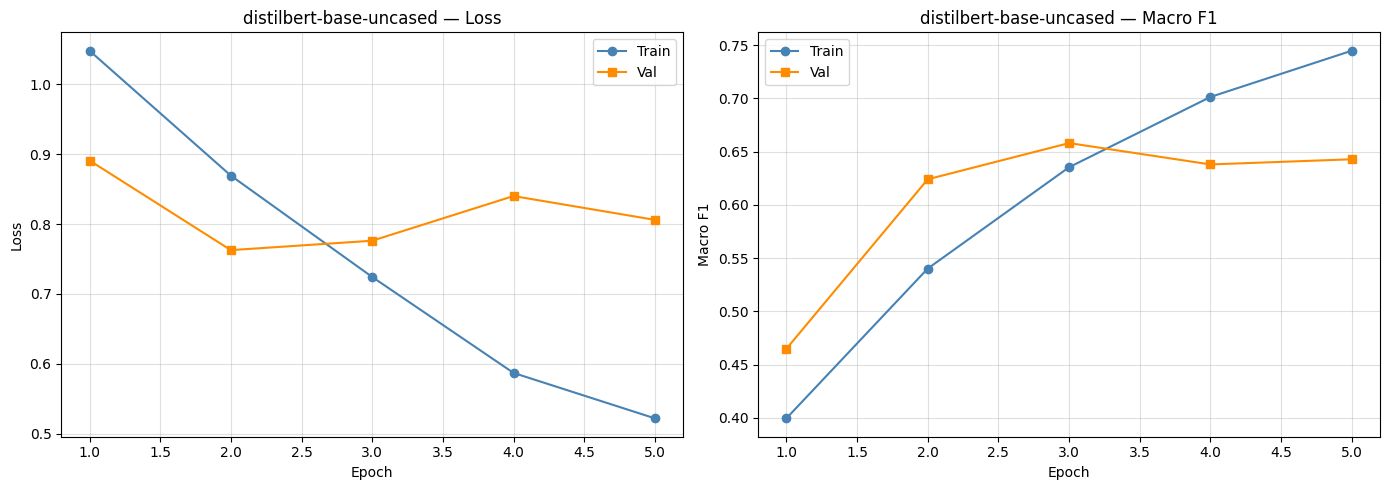

In [9]:
ep = range(1, len(distil_hist["train_loss"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(ep, distil_hist["train_loss"], marker="o", label="Train", color="steelblue")
axes[0].plot(ep, distil_hist["val_loss"],   marker="s", label="Val",   color="darkorange")
axes[0].set_title("distilbert-base-uncased — Loss"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(True, alpha=0.4)
axes[1].plot(ep, distil_hist["train_f1"], marker="o", label="Train", color="steelblue")
axes[1].plot(ep, distil_hist["val_f1"],   marker="s", label="Val",   color="darkorange")
axes[1].set_title("distilbert-base-uncased — Macro F1"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Macro F1")
axes[1].legend(); axes[1].grid(True, alpha=0.4)
plt.tight_layout(); plt.savefig("training_curves_distilbert.png", dpi=300); plt.show()

=== distilbert-base-uncased — Validation Results ===
                 precision    recall  f1-score   support

    Clear Reply       0.74      0.73      0.73       204
     Ambivalent       0.66      0.69      0.68        36
Clear Non-Reply       0.56      0.57      0.57       105

       accuracy                           0.68       345
      macro avg       0.65      0.66      0.66       345
   weighted avg       0.68      0.68      0.68       345



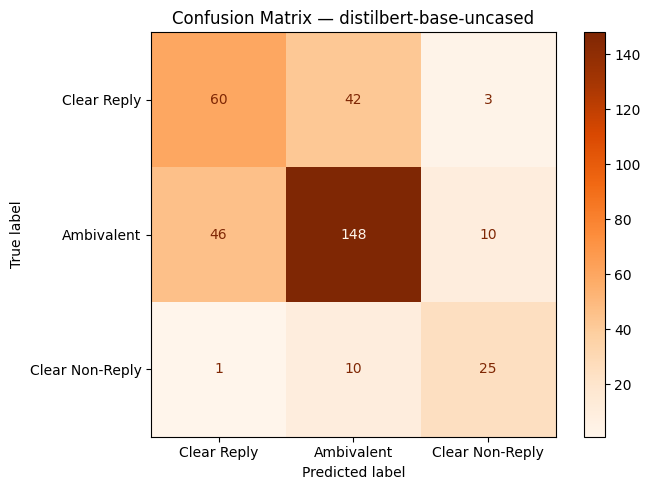

In [10]:
print("=== distilbert-base-uncased — Validation Results ===")
print(classification_report(distil_val_labels, distil_val_preds, target_names=LABELS))
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(distil_val_labels, distil_val_preds, labels=LABELS),
    display_labels=LABELS,
).plot(ax=ax, colorbar=True, cmap="Oranges")
ax.set_title("Confusion Matrix — distilbert-base-uncased")
plt.tight_layout(); plt.savefig("confusion_matrix_distilbert.png", dpi=300); plt.show()

In [11]:
pd.DataFrame({"Id": df_test["index"], "Predicted": distil_test_preds}).to_csv(
    "/kaggle/working/submission_distilbert-base-uncased.csv", index=False
)
pd.DataFrame({"Id": df_test["index"], "Predicted": distil_test_preds}).to_csv(
    "/kaggle/working/submission.csv", index=False
)
print("submission_distilbert-base-uncased.csv saved.")
print(pd.Series(distil_test_preds).value_counts())

submission_distilbert-base-uncased.csv saved.
Ambivalent         177
Clear Reply         91
Clear Non-Reply     40
Name: count, dtype: int64


=== Error Analysis: distilbert-base-uncased ===
Errors: 112 / 345  (32.5%)
Confusion breakdown (true -> predicted):
     true_label      pred_label  count
     Ambivalent Clear Non-Reply     10
     Ambivalent     Clear Reply     46
Clear Non-Reply      Ambivalent     10
Clear Non-Reply     Clear Reply      1
    Clear Reply      Ambivalent     42
    Clear Reply Clear Non-Reply      3
 Hardest class: Ambivalent
  Q:  Any messages for him?
  A: Sure. First of all, Presidents don't recruit; the people elect a leader with whom I will work. And I had a— I did talk to President-elect Sarkozy; I think it was at about 8:03 Pari
  True: Ambivalent  |  Pred: Clear Reply
  ------------------------------------------------------------
  Q: [Determining how a certain action would be implemented]
  A: Very simple. I mean we have—we have all the cards because, without us, you can't come into the United States. It's like if you're a landlord, and you have a tenant. The tenant's bu
  True: Ambivalent 

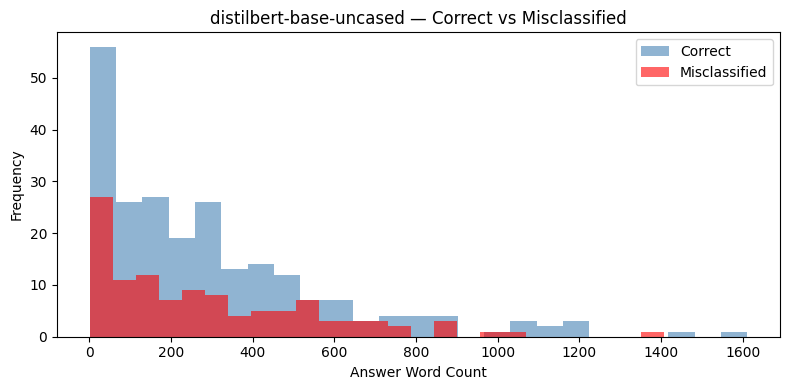

In [12]:
df_err = df_val.copy()
df_err["true_label"] = distil_val_labels
df_err["pred_label"] = distil_val_preds
df_err["correct"]    = (df_err["true_label"] == df_err["pred_label"]).astype(int)
errors = df_err[df_err["correct"] == 0]

print(f"=== Error Analysis: distilbert-base-uncased ===")
print(f"Errors: {len(errors)} / {len(df_err)}  ({100*len(errors)/len(df_err):.1f}%)")
print("Confusion breakdown (true -> predicted):")
print(errors.groupby(["true_label", "pred_label"]).size().reset_index(name="count").to_string(index=False))

hardest = errors["true_label"].value_counts().idxmax()
print(f" Hardest class: {hardest}")
for _, row in errors[errors["true_label"] == hardest].head(2).iterrows():
    print(f"  Q: {str(row['question'])[:120]}")
    print(f"  A: {str(row['interview_answer'])[:180]}")
    print(f"  True: {row['true_label']}  |  Pred: {row['pred_label']}")
    print("  " + "-"*60)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df_err[df_err["correct"]==1]["a_length"], bins=25, alpha=0.6, label="Correct",       color="steelblue")
ax.hist(df_err[df_err["correct"]==0]["a_length"], bins=25, alpha=0.6, label="Misclassified", color="red")
ax.set_xlabel("Answer Word Count"); ax.set_ylabel("Frequency")
ax.set_title("distilbert-base-uncased — Correct vs Misclassified")
ax.legend()
plt.tight_layout(); plt.savefig("error_analysis_distil.png", dpi=300); plt.show()


In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score
y_true, y_pred = distil_val_labels, distil_val_preds
print("="*60)
print(f"Model     : distilbert-base-uncased")
print(f"Accuracy  : {accuracy_score(y_true, y_pred):.4f}")
print(f"Macro F1  : {f1_score(y_true, y_pred, average='macro'):.4f}")
print(f"Precision : {precision_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"Recall    : {recall_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print("="*60)


Model     : distilbert-base-uncased
Accuracy  : 0.6754
Macro F1  : 0.6581
Precision : 0.6529
Recall    : 0.6638
